# Solicitação Interna – Área de Inteligência

De: Gerência de Planejamento e Abastecimento  
Para: Analista de Dados Jr  
Assunto: Análise de Vendas e Apoio à Previsão de Demanda  

Olá,

Estamos buscando evoluir nossa capacidade de análise e previsão de vendas para apoiar as áreas de Compras e Abastecimento na tomada de decisão.

Precisamos de uma análise inicial baseada em dados históricos de vendas, com o objetivo de:

- Identificar padrões de comportamento das vendas ao longo do tempo  
- Detectar possíveis tendências ou variações relevantes  
- Criar uma visão inicial de previsão de demanda (mesmo que simplificada)  
- Gerar insights que possam apoiar decisões operacionais  

Essa análise será utilizada como base para futuras evoluções em modelos mais avançados.

Ficamos no aguardo do material.

Atenciosamente,  
Gerência de Planejamento e Abastecimento

# Plano de Análise

Com base na solicitação, será realizada uma análise exploratória dos dados de vendas, com foco em:

- Compreensão do comportamento histórico das vendas  
- Identificação de tendências e padrões  
- Aplicação de uma abordagem inicial de previsão (baseline) utilizando média móvel  

O objetivo é gerar uma primeira visão estruturada da demanda, permitindo apoiar decisões iniciais e orientar futuras evoluções analíticas

In [4]:
!pip install pandas numpy matplotlib    

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 24.6 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 47.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 49.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 53.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 57.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Criação de um período de 120 dias
datas = pd.date_range(start="2025-01-01", periods=120, freq="D")

# Componentes simulados das vendas
tendencia = np.linspace(100, 180, 120)
sazonalidade = 15 * np.sin(np.arange(120) * 2 * np.pi / 7)
ruido = np.random.normal(0, 8, 120)

# Cálculo das vendas simuladas
vendas = tendencia + sazonalidade + ruido

# Evita valores negativos e arredonda
vendas = np.round(np.maximum(vendas, 0)).astype(int)

# Criação do DataFrame
df = pd.DataFrame({
    "data": datas,
    "vendas": vendas
})

df.head()

,data,vendas
0,2025-01-01,104
1,2025-01-02,111
2,2025-01-03,121
3,2025-01-04,121
4,2025-01-05,94


In [7]:
df.to_csv("../data/vendas_simuladas.csv", index=False)

In [8]:
df = pd.read_csv("../data/vendas_simuladas.csv")
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

df.head()

,vendas
data,
2025-01-01,104
2025-01-02,111
2025-01-03,121
2025-01-04,121
2025-01-05,94


## 📊 Análise Exploratória de Dados

Nesta etapa, analisamos o comportamento das vendas ao longo do tempo, com o objetivo de identificar padrões, tendências e possíveis variações relevantes para o negócio.    

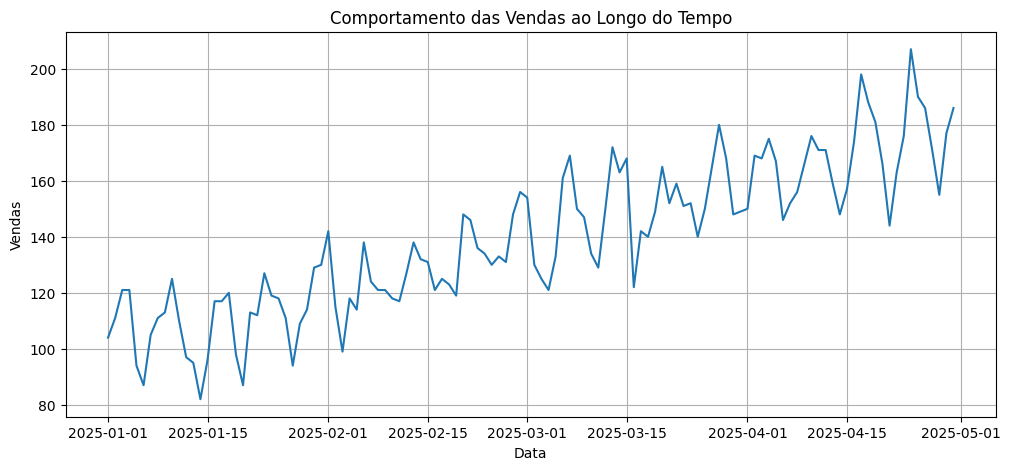

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['vendas'])
plt.title('Comportamento das Vendas ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.grid()
plt.show()

In [15]:
df['media_movel'] = df['vendas'].rolling(window=7).mean()

In [12]:
df.describe()

,vendas
count,120.000000
mean,139.358333
std,26.823042
min,82.000000
25%,119.000000
50%,138.000000
75%,159.500000
max,207.000000


## 📊 Estatísticas Descritivas

- A média de vendas representa o nível típico da demanda no período  
- O desvio padrão indica a variabilidade das vendas, importante para avaliar risco operacional  
- Valores mínimos e máximos ajudam a identificar possíveis extremos de demanda  

Essas métricas são fundamentais para decisões como dimensionamento de estoque e planejamento de compras.

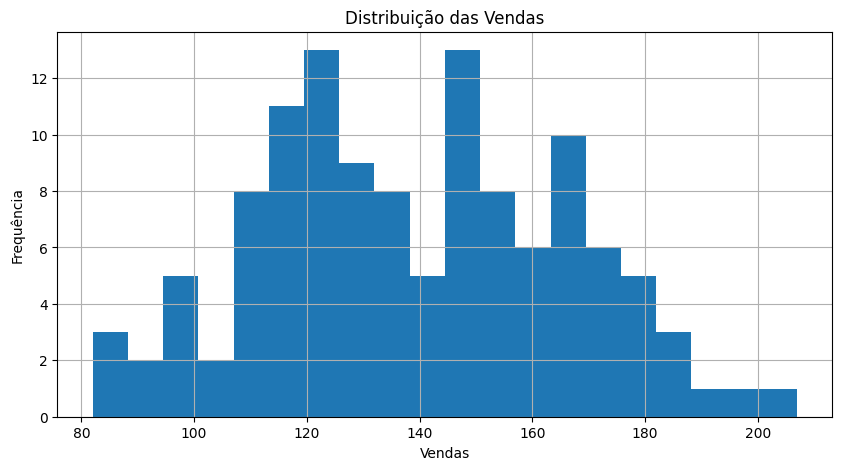

In [13]:
plt.figure(figsize=(10,5))
plt.hist(df['vendas'], bins=20)
plt.title('Distribuição das Vendas')
plt.xlabel('Vendas')
plt.ylabel('Frequência')
plt.grid()
plt.show()

## 🔍 Análise da Distribuição

- A distribuição das vendas permite entender a frequência dos níveis de demanda  
- Caso haja concentração em determinadas faixas, isso indica comportamento padrão da operação  
- Assimetria ou caudas podem indicar picos de demanda ou eventos específicos  

Esse tipo de análise é útil para prever cenários extremos e evitar rupturas ou excesso de estoque.

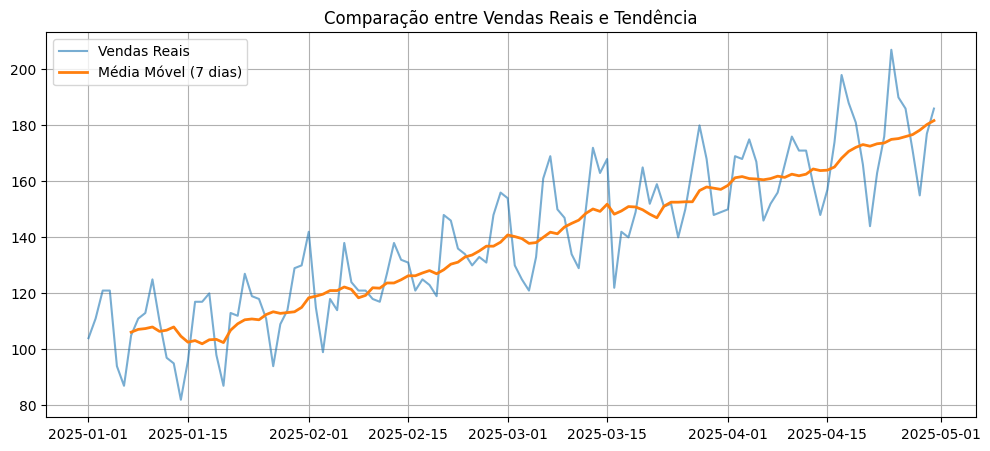

In [16]:
plt.figure(figsize=(12,5))

plt.plot(df['vendas'], label='Vendas Reais', alpha=0.6)
plt.plot(df['media_movel'], label='Média Móvel (7 dias)', linewidth=2)

plt.title('Comparação entre Vendas Reais e Tendência')
plt.legend()
plt.grid()
plt.show()

In [17]:
df['dia_semana'] = df.index.dayofweek

media_por_dia = df.groupby('dia_semana')['vendas'].mean()

media_por_dia

dia_semana
0    125.647059
1    131.352941
2    137.833333
3    151.823529
4    150.470588
5    147.235294
6    131.235294
Name: vendas, dtype: float64

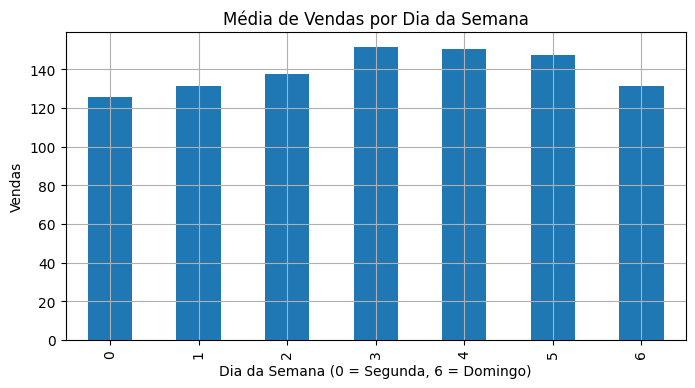

In [18]:
plt.figure(figsize=(8,4))

media_por_dia.plot(kind='bar')

plt.title('Média de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana (0 = Segunda, 6 = Domingo)')
plt.ylabel('Vendas')
plt.grid()

plt.show()

## 📅 Análise de Sazonalidade Semanal

- Observa-se variação no volume médio de vendas entre os dias da semana  
- Esse comportamento indica a presença de um padrão semanal na demanda  
- Em contextos reais de varejo, esse tipo de padrão pode estar associado a:
  - maior fluxo de clientes em determinados dias  
  - promoções específicas  
  - comportamento de consumo  

A identificação dessa sazonalidade permite decisões mais assertivas, como:

- ajuste de estoque por dia da semana  
- planejamento de reposição  
- alocação de recursos operacionais  

Esse tipo de análise é fundamental como base para modelos de previsão mais avançados.

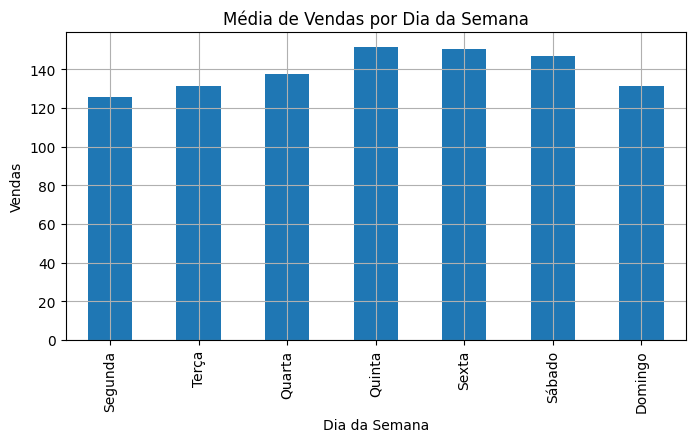

In [19]:
dias = {
    0: 'Segunda',
    1: 'Terça',
    2: 'Quarta',
    3: 'Quinta',
    4: 'Sexta',
    5: 'Sábado',
    6: 'Domingo'
}

media_por_dia.index = media_por_dia.index.map(dias)

media_por_dia.plot(kind='bar', figsize=(8,4))

plt.title('Média de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Vendas')
plt.grid()

plt.show()